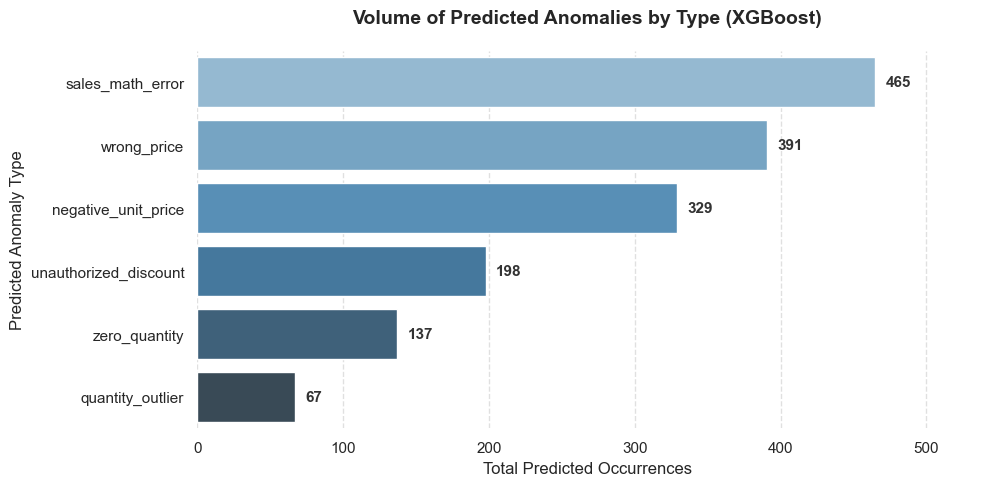

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load the XGBoost prediction results
df = pd.read_csv("output/xgb_predicted_all2.csv")

# Set a professional, crisp plotting style matching previous charts
sns.set_theme(style="white")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16
})

plt.figure(figsize=(10, 5))

# Filter out normal transactions to focus on predicted anomalies
predicted_anomalies = df[df['predicted_type'] != 'normal']['predicted_type'].value_counts()

ax = sns.barplot(
    x=predicted_anomalies.values, 
    y=predicted_anomalies.index, 
    palette="Blues_d",
    hue=predicted_anomalies.index,
    legend=False
)

ax.xaxis.grid(True, linestyle="--", alpha=0.6, color="#CCCCCC")
ax.set_axisbelow(True)
sns.despine(left=True, bottom=True)

# Annotate counts
for i, count in enumerate(predicted_anomalies.values):
    ax.text(
        count + (predicted_anomalies.max() * 0.015), 
        i, 
        f"{int(count):,}", 
        va='center', fontweight='bold', color='#333333'
    )

plt.title("Volume of Predicted Anomalies by Type (XGBoost)", pad=20, fontweight="bold")
plt.xlabel("Total Predicted Occurrences")
plt.ylabel("Predicted Anomaly Type")
plt.xlim(0, predicted_anomalies.max() * 1.15)
plt.tight_layout()
plt.show()


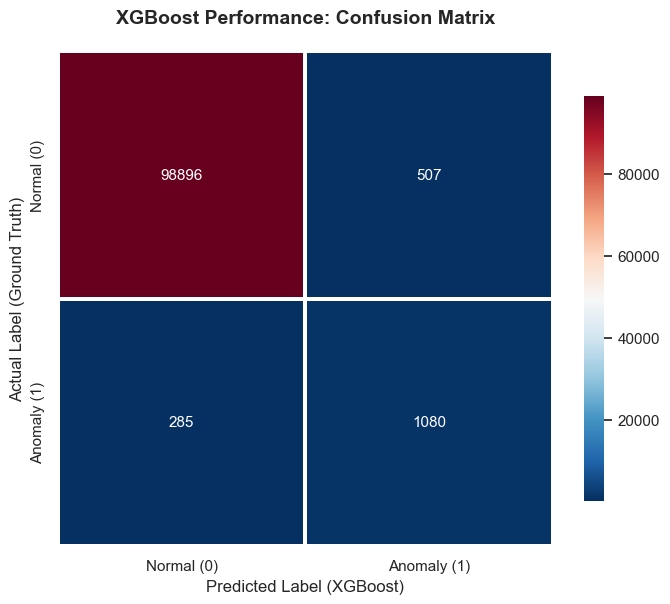

In [3]:

plt.figure(figsize=(7, 6))

# Generate confusion matrix if actual 'anomaly_flag' exists
if 'anomaly_flag' in df.columns and 'predicted_anomaly' in df.columns:
    cm = confusion_matrix(df['anomaly_flag'], df['predicted_anomaly'])
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="RdBu_r", 
        square=True, 
        linewidths=1.5,
        cbar_kws={"shrink": 0.8},
        xticklabels=["Normal (0)", "Anomaly (1)"],
        yticklabels=["Normal (0)", "Anomaly (1)"]
    )
    
    plt.title("XGBoost Performance: Confusion Matrix", pad=20, fontweight="bold")
    plt.xlabel("Predicted Label (XGBoost)")
    plt.ylabel("Actual Label (Ground Truth)")
    plt.tight_layout()
    plt.show()


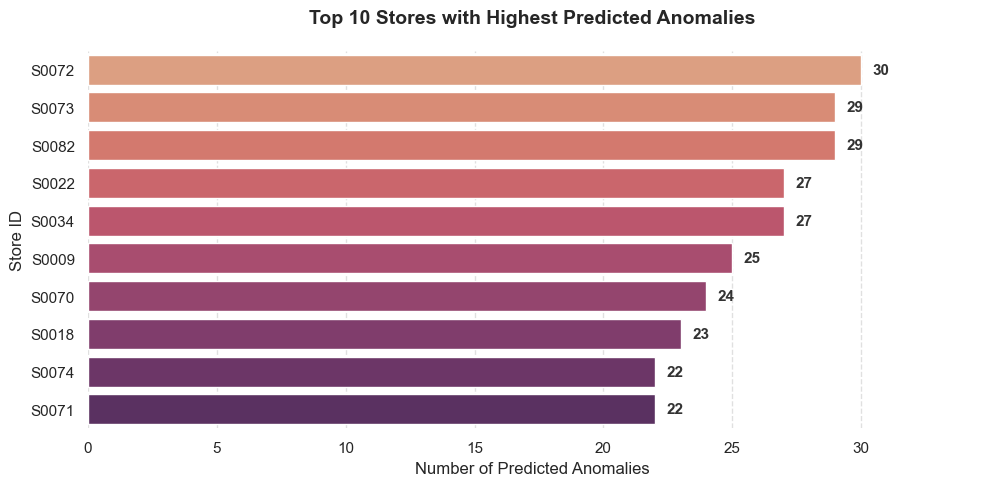

In [4]:
plt.figure(figsize=(10, 5))

# Group by store and count predicted anomalies
store_anomalies = df[df['predicted_anomaly'] == 1].groupby('store_id').size().sort_values(ascending=False).head(10)

ax2 = sns.barplot(
    x=store_anomalies.values, 
    y=store_anomalies.index, 
    palette="flare", 
    hue=store_anomalies.index, 
    legend=False
)

ax2.xaxis.grid(True, linestyle="--", alpha=0.6, color="#CCCCCC")
ax2.set_axisbelow(True)
sns.despine(left=True, bottom=True)

# Annotate counts
for i, count in enumerate(store_anomalies.values):
    ax2.text(
        count + (store_anomalies.max() * 0.015), 
        i, 
        f"{int(count):,}", 
        va='center', fontweight='bold', color='#333333'
    )

plt.title("Top 10 Stores with Highest Predicted Anomalies", pad=20, fontweight="bold")
plt.xlabel("Number of Predicted Anomalies")
plt.ylabel("Store ID")
plt.xlim(0, store_anomalies.max() * 1.15)
plt.tight_layout()
plt.show()


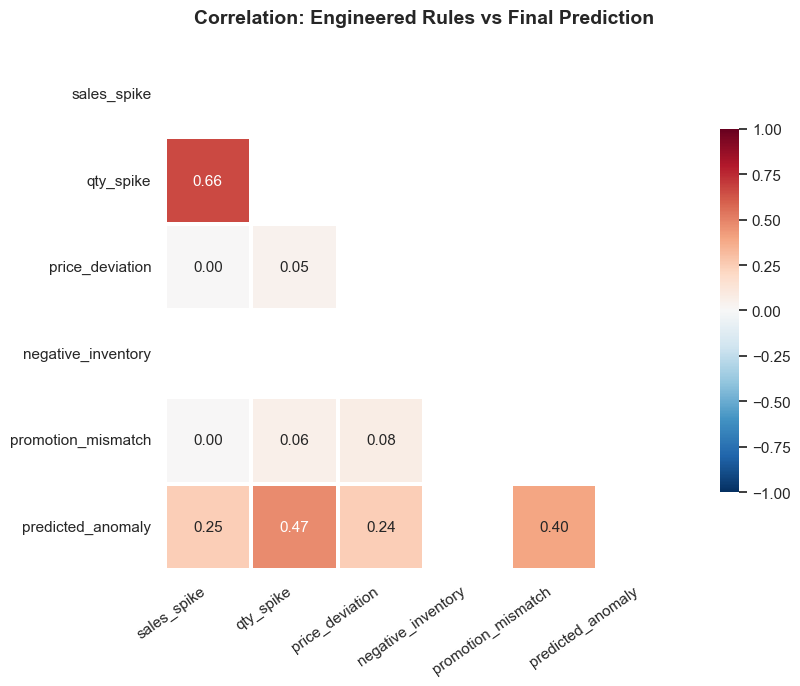

In [5]:
plt.figure(figsize=(9, 7))

# Select the rule-based flags and the final prediction target
rule_cols = ['sales_spike', 'qty_spike', 'price_deviation', 'negative_inventory', 'promotion_mismatch', 'predicted_anomaly']
valid_rule_cols = [col for col in rule_cols if col in df.columns]

if len(valid_rule_cols) > 1:
    corr_matrix = df[valid_rule_cols].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap="RdBu_r",
        vmin=-1.0, vmax=1.0,
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=1.5,
        cbar_kws={"shrink": 0.7}
    )
    
    plt.title("Correlation: Engineered Rules vs Final Prediction", pad=20, fontweight="bold")
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()